# 1. Scalars, vectors and matrices

Learn to describe numerical objects by their shapes, add compatible vectors, calculate a dot product manually, and interpret matrix multiplication as a batch of weighted sums. Prerequisites: the introductory Python, NumPy, pandas, and visualization lessons. You need multiplication and addition; no prior linear algebra is assumed. Allow two to three hours with paper beside the notebook.

## 2. What problem does this solve?

A prediction may depend on several measurements. A house has an area, age, and distance from transit. We need a compact way to organize one house's measurements, many houses' measurements, and the weights applied to them. Linear algebra supplies this language and the corresponding operations.

Writing a prediction as a matrix operation is not merely shorthand. It reveals which dimensions must agree, which outputs are produced, and how the same rule is applied to a whole dataset. Shape reasoning catches many implementation errors before any training begins.

## 3. Intuition and analogy

A scalar is one labeled box containing a number. A vector is an ordered row of boxes. A matrix is a rectangular shelving unit. Rearranging the shelves changes how the contents should be interpreted. A shopping basket gives an intuitive weighted sum: multiply each item's quantity by its price, then add the costs.

The ordering of quantities and prices must agree. Multiplying bread quantity by pie price and pie quantity by bread price is dimensionally executable but semantically wrong. Keep feature names and ordering alongside numerical arrays.

## 4. Terminology

A **scalar** is a single number, such as a service fee. A **vector** is an ordered collection of numbers. A **matrix** is a two-dimensional rectangular array. A **tensor** is a more general multidimensional numerical object; here we use the computational array meaning rather than a full mathematical treatment of tensors.

A **dot product** multiplies corresponding entries of two equal-length vectors and sums them. A **transpose** exchanges matrix rows and columns. A **linear combination** scales objects and adds them. A **norm** measures magnitude under a specified rule. **Dimension** can mean vector length or number of array axes; state which meaning is intended.

## 5. Mathematical foundations

For quantities $x=(x_1,x_2)$ and prices $w=(w_1,w_2)$,

$$x^T w=x_1w_1+x_2w_2.$$

$x_j$ is the quantity of item $j$, in items; $w_j$ is its price, in currency units per item. Each product is a cost in currency units, so the sum is meaningful. Mathematically we often describe $x$ and $w$ as column vectors with shape $(2,1)$, and $x^T$ as a row with shape $(1,2)$. NumPy's one-dimensional `(2,)` array has neither orientation until we explicitly reshape it.

For a table $X$ with $n$ rows and $p$ columns, and weights $w$ of length $p$,

$$z=Xw,\qquad z_i=\sum_{j=1}^{p}X_{ij}w_j.$$

The result has one weighted sum per row, shape $(n,)$ in NumPy. In ordinary matrix notation, $(n,p)$ times $(p,1)$ produces $(n,1)$. The shared inner dimension $p$ must agree.

## 6. Hand-calculated example

The first basket contains two loaves and one pie. Prices are three units per loaf and five per pie. Its cost is $2\times3+1\times5=11$. A second basket contains one loaf and two pies: $1\times3+2\times5=13$. Place baskets into rows of $X=[[2,1],[1,2]]$ and prices into $w=[3,5]$. Then $Xw=[11,13]$.

An added service fee of two currency units produces totals `[13,15]`. The fee is a scalar added to each output. A weighted sum plus a constant is called affine; a strictly linear map has no added constant. ML often calls both kinds “linear models,” so terminology needs care.

## 7. Implementation from scratch

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
baskets = [[2, 1], [1, 2]]
prices = [3, 5]
manual_costs = []
for basket in baskets:
    assert len(basket) == len(prices)
    cost = sum(quantity * price for quantity, price in zip(basket, prices))
    manual_costs.append(cost)
print('Weighted sums:', manual_costs)
assert manual_costs == [11, 13]

Weighted sums: [11, 13]


## 8. Step-by-step output inspection

In [3]:
import numpy as np
X = np.array(baskets, dtype=float)
w = np.array(prices, dtype=float)
contributions = X * w
print('Per-item costs:\n', contributions)
print('Shapes:', X.shape, w.shape, contributions.shape)
np.testing.assert_allclose(contributions, [[6, 5], [3, 10]])

Per-item costs:
 [[ 6.  5.]
 [ 3. 10.]]
Shapes: (2, 2) (2,) (2, 2)


The elementwise product retains two columns. Summing those columns is still necessary to obtain one total per basket. Printing the intermediate costs reveals whether a wrong result came from multiplication, ordering, or summation.

## 9. Library implementation

In [4]:
costs = X @ w
np.testing.assert_allclose(costs, manual_costs)
np.testing.assert_allclose(costs, contributions.sum(axis=1))
column_result = X @ w.reshape(2, 1)
assert costs.shape == (2,) and column_result.shape == (2, 1)
np.testing.assert_allclose(column_result[:, 0], costs)
print('Matrix-vector result:', costs)
print('With service fee:', costs + 2)

Matrix-vector result: [11. 13.]
With service fee: [13. 15.]


The `@` operator performs matrix multiplication. The library uses efficient numerical routines and handles many compatible shapes; our loop explains only this simple case. Matching values is not sufficient if an unexpected result shape later triggers incorrect broadcasting.

## 10. Visualization

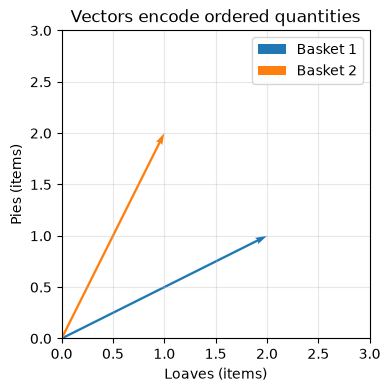

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display
fig, ax = plt.subplots(figsize=(5, 4))
for vector, label, color in [([2, 1], 'Basket 1', 'tab:blue'), ([1, 2], 'Basket 2', 'tab:orange')]:
    ax.quiver(0, 0, *vector, angles='xy', scale_units='xy', scale=1, color=color, label=label)
ax.set(xlim=(0, 3), ylim=(0, 3), xlabel='Loaves (items)', ylabel='Pies (items)', title='Vectors encode ordered quantities')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend()
display(fig)
plt.close(fig)

Both arrows start at zero and end at the basket's quantities. Swapping coordinates changes which product is abundant. The geometric picture is useful here because the axes represent comparable counts; in a feature vector with age and income, geometric distance depends strongly on units and scaling.

## 11. Realistic experiment: unit conversions

Suppose bread quantity is recorded in dozens rather than individual loaves. Quantities divide by twelve and price per dozen multiplies by twelve. The cost should remain unchanged. This gives a powerful consistency check independent of exact numerical examples.

In [6]:
X_dozens = X.copy()
X_dozens[:, 0] /= 12
w_dozens = w.copy()
w_dozens[0] *= 12
np.testing.assert_allclose(X_dozens @ w_dozens, costs)
print('Cost is invariant under a consistent unit conversion.')

Cost is invariant under a consistent unit conversion.


If you change only quantities, predictions change for a purely representational reason. A model trained on one unit system must receive the same system at inference, or a consistently transformed version with matching parameters.

## 12. Choices and experiments

There is no training algorithm in this notebook: prices were supplied, not learned. In a regression model, weights would be estimated from examples, while feature choice and regularization strength would be chosen by us. Here experiment by changing one weight and predicting which baskets' totals change most. A basket with more of that product is more sensitive to its weight.

## 13. Evaluation

Use manual calculations, shape checks, and unit invariance. Vector addition should be elementwise: `[2,1]+[1,2]=[3,3]` when the coordinates have matching meaning. A norm such as $\|x\|_2=\sqrt{x_1^2+x_2^2}$ measures Euclidean length; for `[3,4]` it equals five. That length is not the sum of purchases, which would be seven.

## 14. Assumptions and limitations

Weighted sums assume additive contributions. Bulk discounts or interactions between products require a different rule. A geometric distance between mixed-unit features may be dominated by whichever numerical scale is larger. A matrix is a representation, not proof that the underlying relationship is linear.

## 15. Common mistakes and debugging

Do not confuse `*` and `@`. Do not assume transposing a one-dimensional array makes a column: `w.T` still has shape `(2,)`. Use `reshape(-1,1)` to create one explicitly. Never reorder feature columns at prediction time without reordering weights. If the dimensions match only because two unrelated counts happen to be equal, the operation can still be conceptually invalid.

## 16. Comparison with alternatives

A scalar model uses one setting. A vector stores multiple ordered settings. A matrix applies or records relationships across many objects. Higher-dimensional arrays naturally store batches of images or sequences. pandas can preserve column labels before conversion to numerical arrays; arrays trade those labels for direct numerical operations.

## 17. Exercises

1. **Beginner:** Identify scalar, vector, and matrix examples in a class-grade dataset.
2. **Beginner:** Calculate `[4,2]` dotted with `[3,5]` by hand.
3. **Beginner:** State the result shape of a `(7,3)` table multiplied by a length-three vector.
4. **Intermediate:** Give a concrete example where elementwise multiplication and matrix multiplication produce different results or shapes.
5. **Intermediate:** Explain why exchanging the feature columns while keeping weights fixed can be wrong even when shapes match.
6. **Challenge:** Derive the change in every prediction when one weight $w_j$ increases by a small amount $d$, and verify with code.

## 18. Detailed solutions

1. One student's average is a scalar; one student's three exam marks form a vector; all students' marks form a matrix with one row per student.
2. $4\times3+2\times5=22$ currency units.
3. There are seven rowwise sums, so NumPy returns shape `(7,)`.
4. In our example `X*w` gives the `(2,2)` contribution table, while `X@w` gives the `(2,)` vector of totals.
5. A row `[2 loaves,1 pie]` would be interpreted as two pies and one loaf. Shapes cannot encode the missing semantics.
6. Only the term containing weight $j$ changes: $X_{ij}(w_j+d)-X_{ij}w_j=dX_{ij}$. The prediction change vector is $dX_{:j}$, the selected column scaled by $d$.

In [7]:
d = 0.5
changed = w.copy()
changed[0] += d
np.testing.assert_allclose(X @ changed - X @ w, d * X[:, 0])
assert np.dot([4, 2], [3, 5]) == 22
assert np.linalg.norm([3, 4]) == 5
print('Prediction changes:', X @ changed - X @ w)

Prediction changes: [1.  0.5]


## 19. Knowledge check

**Does order matter?** Yes; entries must match feature meanings. **What does transpose do?** Exchanges matrix axes. **What is a dot product's output?** One scalar for two equal-length vectors. **Are supplied prices learned parameters?** Not in this example. **Why track units?** To ensure summed contributions represent the same kind of quantity.

## 20. Interview preparation

**What are matrix multiplication's shape rules?** Inner dimensions match, outer dimensions describe the output. **Why vectorize predictions?** One operation applies consistent weights to all rows efficiently. **Why can matching dimensions still be wrong?** Feature order or units may be mismatched. **Linear versus affine?** An affine map adds an offset to a linear map. **What does feature scaling change?** Numerical representation and parameter interpretation; without corresponding adjustments it changes predictions or distance geometry.

## 21. Summary and next steps

You can now trace a weighted sum from manual arithmetic to matrix code and explain its units. Continue to [Functions and derivatives](../../../02_Mathematics_for_ML/03_functions_and_derivatives.ipynb), which introduces how outputs change when inputs or parameters move.